# Feature Engineering Phase

## The framing question that shapes everything in this notebook

We're building a **next-day, hourly demand forecast**: once per day, we predict
all 24 hourly demand values for the following day, using only data known by
the end of today. This means **only whole-day-multiple lags are valid**
(24, 48, 72, 168, 336, 720 hours = 1, 2, 3, 7, 14, 30 days).

Rather than picking lag windows by feel, we will validate
them empirically (autocorrelation + permutation importance), add a secular
trend feature, a pandemic-disruption flag, and realistic temperature
forecast uncertainty.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/interim/cleaned_dataset.csv", parse_dates=["datetime"])
df = df.sort_values("datetime").reset_index(drop=True)
df.head()

,Date,Hour,market_demand,ontario_demand,datetime,hoep,temperature_c,hour_of_day,month,year
0,2002-05-01,1,14141,14137,2002-05-01 00:00:00,22.97,3.1,0,5,2002
1,2002-05-01,2,13876,13872,2002-05-01 01:00:00,23.27,2.5,1,5,2002
2,2002-05-01,3,13974,13820,2002-05-01 02:00:00,24.54,1.5,2,5,2002
3,2002-05-01,4,13898,13744,2002-05-01 03:00:00,15.17,1.1,3,5,2002
4,2002-05-01,5,14378,14224,2002-05-01 04:00:00,23.59,1.1,4,5,2002


## 1. Validating lag choices empirically (autocorrelation)

Rather than picking 24/48/168 hours by feel, let's check the demand
series' own autocorrelation structure: how correlated is demand right
now with demand N hours ago, across a range of candidate lags?

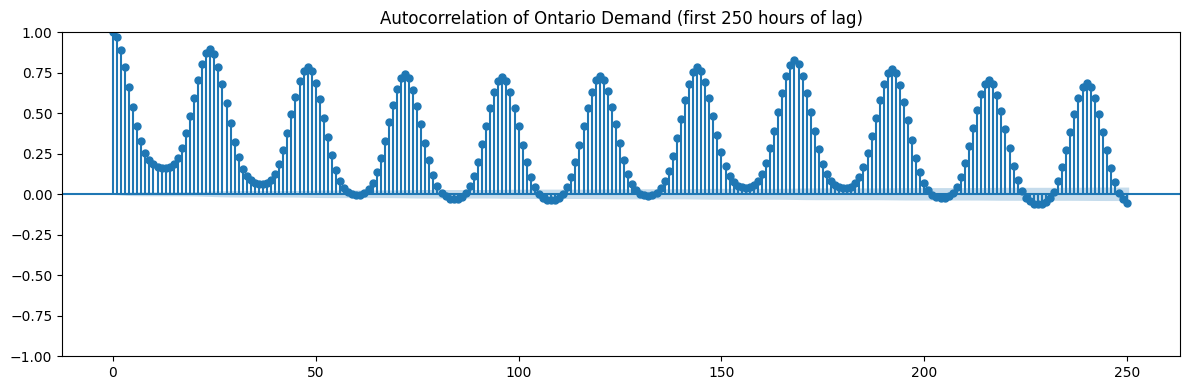

In [18]:
from statsmodels.graphics.tsaplots import plot_acf

# Full ACF plot, zoomed to the first ~250 hours so the daily (24h) and
# weekly (168h) spikes are clearly visible
fig, ax = plt.subplots(figsize=(12, 4))
plot_acf(df['ontario_demand'], lags=250, ax=ax)
plt.title('Autocorrelation of Ontario Demand (first 250 hours of lag)')
plt.tight_layout()
plt.show()

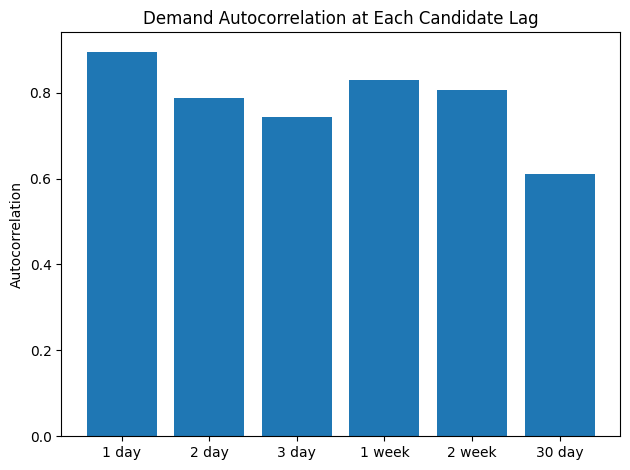

   1 day: 0.896
   2 day: 0.788
   3 day: 0.743
  1 week: 0.830
  2 week: 0.806
  30 day: 0.610


In [ ]:
candidate_lags_hours = [24, 48, 72, 168, 336, 720]  # 1, 2, 3, 7, 14, 30 days
labels = ['1 day', '2 day', '3 day', '1 week', '2 week', '30 day']

# Calculate Pearson correlation coefficients between each demand and the demand `l` hours ago
autocorrs = [df['ontario_demand'].autocorr(lag=l) for l in candidate_lags_hours]

fig, ax = plt.subplots()
ax.bar(labels, autocorrs)
ax.set_ylabel('Autocorrelation')
plt.title('Demand Autocorrelation at Each Candidate Lag')
plt.tight_layout()
plt.show()

# Print coefficients for all candidate lags (a value near 1.0 indicates strong positive linear association, a value near 0.0 means no linear relationship)
for label, ac in zip(labels, autocorrs):
    print(f"{label:>8}: {ac:.3f}")

## 2. Lag features (informed by the ACF check above)

In [ ]:
# We will not include 30 days as the relationship proved to be significantly weaker
LAG_HOURS = [24, 48, 72, 168, 336]  # 1, 2, 3, 7, 14 days

for lag in LAG_HOURS:
    df[f'demand_lag_{lag}h'] = df['ontario_demand'].shift(lag)
    df[f'hoep_lag_{lag}h'] = df['hoep'].shift(lag)

df[['datetime', 'ontario_demand', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h', 'demand_lag_168h', 'demand_lag_336h']].tail(10)

,datetime,ontario_demand,demand_lag_24h,demand_lag_48h,demand_lag_72h,demand_lag_168h,demand_lag_336h
201614,2025-04-30 14:00:00,14198,15630.0,14386.0,12710.0,14362.0,15635.0
201615,2025-04-30 15:00:00,14720,16041.0,14770.0,13087.0,14867.0,15883.0
201616,2025-04-30 16:00:00,15579,16481.0,15192.0,13819.0,15441.0,16292.0
201617,2025-04-30 17:00:00,15910,16296.0,15517.0,14506.0,15788.0,16739.0
201618,2025-04-30 18:00:00,15826,15928.0,15705.0,14872.0,16015.0,17277.0
201619,2025-04-30 19:00:00,16264,15806.0,15860.0,15295.0,16385.0,17651.0
201620,2025-04-30 20:00:00,16183,15524.0,15500.0,15185.0,16108.0,17286.0
201621,2025-04-30 21:00:00,15351,14701.0,14484.0,14580.0,15215.0,16486.0
201622,2025-04-30 22:00:00,14459,13780.0,13356.0,13693.0,14345.0,15517.0
201623,2025-04-30 23:00:00,13795,13106.0,12540.0,13167.0,13562.0,14717.0


## 3. Rolling statistics

Computed on the lagged series (not the raw series) so every value in the
window is guaranteed to be at or before our forecast cutoff (ensuring no
leakage of data that would not have been available at the time of prediction)

In [22]:
# Calculate rolling mean for all lag timeframes (eg. mean of all `ontario_demand` values in the last 24 hours), as well as the standard
# deviation of 3 strongest lags from the ACF check above - could prove valuable that the model has an idea of the variance in the data 
df['demand_rolling_24h_mean'] = df['demand_lag_24h'].rolling(24).mean()
df['demand_rolling_24h_std'] = df['demand_lag_24h'].rolling(24).std()
df['demand_rolling_48h_mean'] = df['demand_lag_24h'].rolling(24 * 2).mean()
df['demand_rolling_72h_mean'] = df['demand_lag_24h'].rolling(24 * 3).mean()
df['demand_rolling_168h_mean'] = df['demand_lag_24h'].rolling(24 * 7).mean()
df['demand_rolling_168h_std'] = df['demand_lag_24h'].rolling(24 * 7).std()
df['demand_rolling_336h_mean'] = df['demand_lag_24h'].rolling(24 * 14).mean()
df['demand_rolling_336h_std'] = df['demand_lag_24h'].rolling(24 * 14).std()

df[['datetime', 'ontario_demand', 'demand_rolling_24h_mean', 'demand_rolling_168h_mean']].tail(10)

,datetime,ontario_demand,demand_rolling_24h_mean,demand_rolling_168h_mean
201614,2025-04-30 14:00:00,14198,14237.250000,14296.744048
201615,2025-04-30 15:00:00,14720,14290.208333,14304.821429
201616,2025-04-30 16:00:00,15579,14343.916667,14313.089286
201617,2025-04-30 17:00:00,15910,14376.375000,14317.636905
201618,2025-04-30 18:00:00,15826,14385.666667,14316.654762
201619,2025-04-30 19:00:00,16264,14383.416667,14313.065476
201620,2025-04-30 20:00:00,16183,14384.416667,14308.880952
201621,2025-04-30 21:00:00,15351,14393.458333,14305.220238
201622,2025-04-30 22:00:00,14459,14411.125000,14301.785714
201623,2025-04-30 23:00:00,13795,14434.708333,14298.833333


## 4. Calendar features

In [23]:
df['hour'] = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek  # Monday=0
df['month'] = df['datetime'].dt.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Using sin and cos to encode cyclical features (hour 23 is adjacent to hour 0, month 12 is adjacent
# to month 1 - and both these relations could be very important to encode when predicting demand). 
# We need both sin and cos to uniquely distinguish each hour/month (eg. some hours will have the
# same `hour_sin`, but never the same combination of `hour_sin` and `hour_cos`)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

df[['datetime', 'hour', 'hour_sin', 'hour_cos', 'is_weekend']].head()

,datetime,hour,hour_sin,hour_cos,is_weekend
0,2002-05-01 00:00:00,0,0.000000,1.000000,0
1,2002-05-01 01:00:00,1,0.258819,0.965926,0
2,2002-05-01 02:00:00,2,0.500000,0.866025,0
3,2002-05-01 03:00:00,3,0.707107,0.707107,0
4,2002-05-01 04:00:00,4,0.866025,0.500000,0


In [24]:
import holidays

# Identify any holidays (could have similar impact to demand as a weekend when compared to a weekday)
on_holidays = holidays.Canada(prov='ON', years=range(2002, 2026))
df['is_holiday'] = df['datetime'].dt.date.astype(str).map(
    lambda d: pd.Timestamp(d) in on_holidays
).astype(int)

## 5. Secular trend feature

Ontario's demand history has not increased over time like population; efficiency
programs and industrial decline drove demand down for years after the mid-2000s,
with EV adoption a newer upward pressure. A plain numeric trend feature lets the
model absorb this non-monotonic history without us having to model each underlying
cause individually.

In [25]:
df['days_since_start'] = (df['datetime'] - df['datetime'].min()).dt.days

## 6. Pandemic disruption flag

COVID-19 lockdowns disrupted normal demand patterns severely enough that
they might be worth flagging as a distinct regime rather than letting the
model treat the period as noisy versions of normal years. The province went
through multiple distinct waves and partial reopenings. We will use a single
broad flag spanning the initial declared state of emergency (March 17, 2020)
through when all remaining capacity limits on indoor public settings were
lifted (March 1, 2022).

In [26]:
PANDEMIC_START = pd.Timestamp('2020-03-17')
PANDEMIC_END = pd.Timestamp('2022-03-01')

df['is_pandemic_period'] = ((df['datetime'] >= PANDEMIC_START) & (df['datetime'] < PANDEMIC_END)).astype(int)
print(f"Rows flagged as pandemic period: {df['is_pandemic_period'].sum():,}")

Rows flagged as pandemic period: 17,136


## 7. Temperature features, with realistic forecast uncertainty

Similar to the leakage issue flagged earlier, using actual observed temperature
as a stand-in for "the weather forecast that would have been available" is
an optimistic simplification. A real deployed system only has a forecasted
temperature at prediction time, not the true value. Rather than pretending
this gap away, we will simulate it: add Gaussian noise to actual temperature
to approximate realistic next-day forecast error, then derive our degree-hour
features from that noisy version.

**Where the noise magnitude comes from:** published
meteorological verification sources consistently report next-day
temperature forecasts as accurate to roughly 1-2°C / 2-3°F on average.
We will use that figure directly as our noise standard deviation.

In [27]:
TEMP_FORECAST_ERROR_STD_C = 1.5  # documented assumption, see markdown above

np.random.seed(42)  # reproducible noise
df['temperature_c_forecast'] = df['temperature_c'] + np.random.normal(
    loc=0, scale=TEMP_FORECAST_ERROR_STD_C, size=len(df)
)

# Baseline temperature without any heating/cooling demand is known to be 18.0 degrees celsius
BASELINE_TEMP_C = 18.0
df['heating_degree_hours'] = (BASELINE_TEMP_C - df['temperature_c_forecast']).clip(lower=0)
df['cooling_degree_hours'] = (df['temperature_c_forecast'] - BASELINE_TEMP_C).clip(lower=0)

df[['datetime', 'temperature_c', 'temperature_c_forecast', 'heating_degree_hours', 'cooling_degree_hours']].head()

,datetime,temperature_c,temperature_c_forecast,heating_degree_hours,cooling_degree_hours
0,2002-05-01 00:00:00,3.1,3.845071,14.154929,0.0
1,2002-05-01 01:00:00,2.5,2.292604,15.707396,0.0
2,2002-05-01 02:00:00,1.5,2.471533,15.528467,0.0
3,2002-05-01 03:00:00,1.1,3.384545,14.615455,0.0
4,2002-05-01 04:00:00,1.1,0.748770,17.251230,0.0


## 8. Correlation matrix

Before running the actual importance experiment, a correlation matrix is a
cheap first pass: it flags redundant features (e.g. `demand_rolling_24h_mean` and
`demand_rolling_48h_mean` are likely highly correlated with each other) and
gives a first look at which features correlate most with the target.

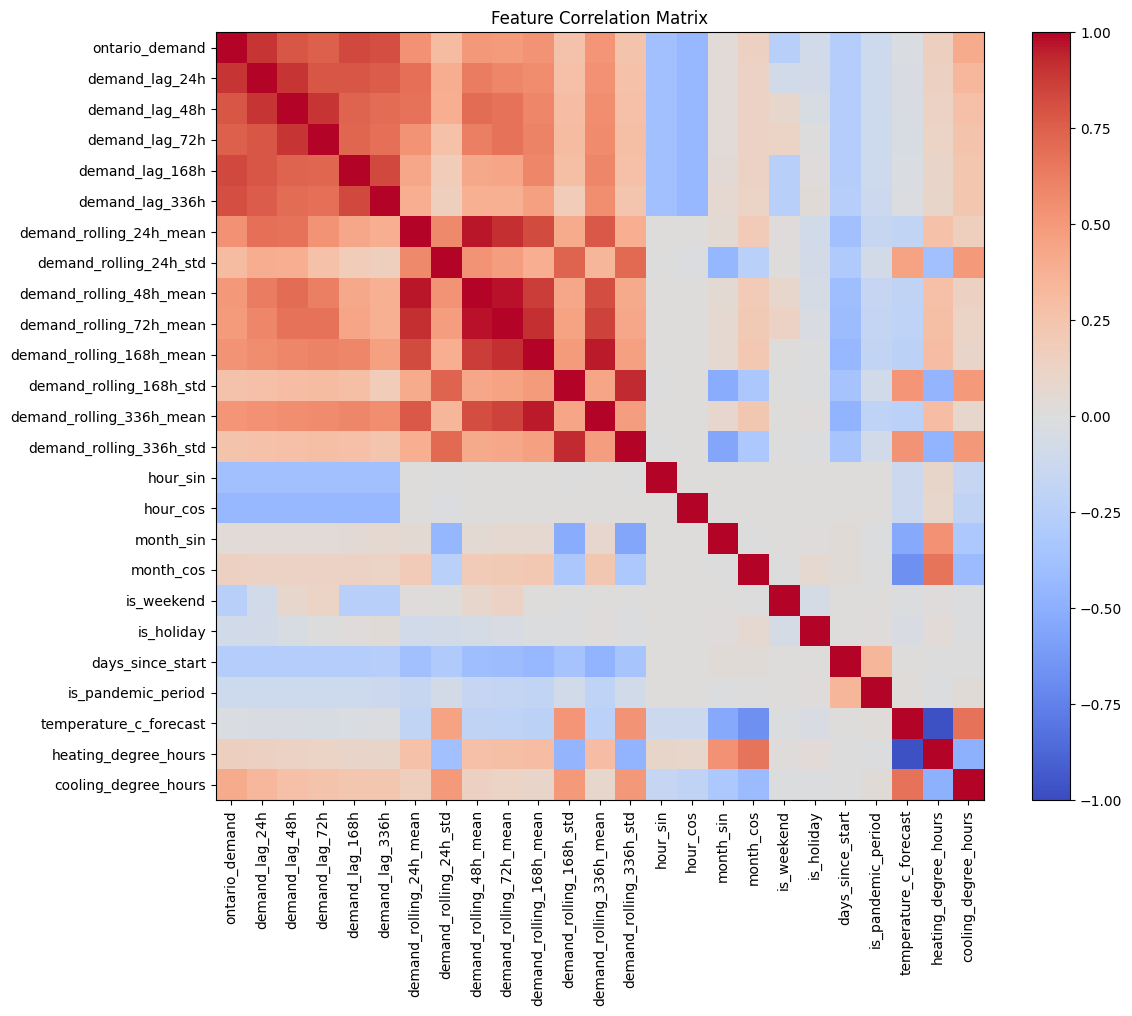

In [28]:
corr_features = [
    'ontario_demand', 'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h',
    'demand_lag_168h', 'demand_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std',
    'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean',
    'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_holiday',
    'days_since_start', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours',
    'cooling_degree_hours'
]

corr_matrix = df[corr_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=90)
ax.set_yticklabels(corr_features)
fig.colorbar(im)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 9. Permutation importance

Correlation only looks at features one at a time; it can't tell you
whether a feature adds anything once every OTHER feature is already in the
model. Permutation importance answers that directly by training a model on the
full candidate feature set, then for each feature, shuffle its values
randomly and measure how much the model's accuracy gets worse. A feature
that matters a lot will hurt badly when shuffled while a useless one won't move
the needle.

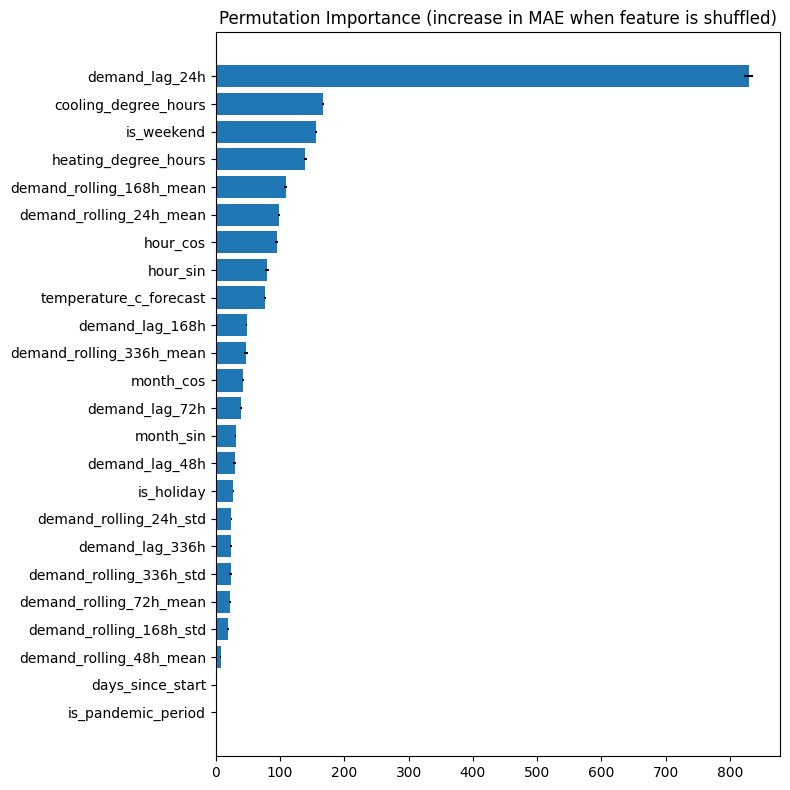

,feature,importance_mean,importance_std
0,demand_lag_24h,829.097229,7.142943
23,cooling_degree_hours,167.278784,1.577939
17,is_weekend,156.002991,1.930891
22,heating_degree_hours,139.146802,2.600363
9,demand_rolling_168h_mean,108.519885,2.158833
5,demand_rolling_24h_mean,97.672937,1.511990
14,hour_cos,94.821606,2.113224
13,hour_sin,79.289087,2.906738
21,temperature_c_forecast,76.638184,1.754110
3,demand_lag_168h,47.798840,0.612604


In [ ]:
from xgboost import XGBRegressor
from sklearn.inspection import permutation_importance

candidate_features = [
    'demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h',
    'demand_lag_168h', 'demand_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std',
    'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean',
    'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std',
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_holiday',
    'days_since_start', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours',
    'cooling_degree_hours'
]

# Train on all hours pre-2021 and use 2021 as validation dataset
diag_df = df.dropna(subset=candidate_features + ['ontario_demand'])
diag_train = diag_df[diag_df['datetime'] < '2021-01-01']
diag_val = diag_df[(diag_df['datetime'] >= '2021-01-01') & (diag_df['datetime'] < '2022-01-01')]

# Train XGBoost model configured with 200 trees and a max depth of 6 on the training set
diag_model = XGBRegressor(n_estimators=200, max_depth=6, random_state=42)
diag_model.fit(diag_train[candidate_features], diag_train['ontario_demand'])

# Evaluate feature importance by measuring how much the validation score drops when the feature's values are shuffled
# Shuffle each feature 5 separate times and MAE across the 5 tests is used as the scoring metric
perm_result = permutation_importance(
    diag_model, diag_val[candidate_features], diag_val['ontario_demand'],
    n_repeats=5, random_state=42, scoring='neg_mean_absolute_error',
)

importance_df = pd.DataFrame({
    'feature': candidate_features,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(importance_df['feature'], importance_df['importance_mean'], xerr=importance_df['importance_std'])
ax.invert_yaxis()
plt.title('Permutation Importance (increase in MAE when feature is shuffled)')
plt.tight_layout()
plt.show()

importance_df

## 10. Final feature list

In [ ]:
# Adjust this list based on your permutation importance results above --
# starting point below keeps everything tested; trim what scored near zero.
feature_cols = candidate_features.copy()

# Remove days_since_start due to low feature importance (tree extrapolation limitation)
feature_cols.remove('days_since_start')

# Also remove days_since_start from df, as well as other unused columns
df = df.drop(columns=['Date', 'Hour', 'hour_of_day', 'month', 'year', 'hour', 'day_of_week', 'days_since_start'])
target_col = 'ontario_demand'

print(f"Feature count: {len(feature_cols)}")
print(feature_cols)
print(df.columns)

Feature count: 23
['demand_lag_24h', 'demand_lag_48h', 'demand_lag_72h', 'demand_lag_168h', 'demand_lag_336h', 'demand_rolling_24h_mean', 'demand_rolling_24h_std', 'demand_rolling_48h_mean', 'demand_rolling_72h_mean', 'demand_rolling_168h_mean', 'demand_rolling_168h_std', 'demand_rolling_336h_mean', 'demand_rolling_336h_std', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_holiday', 'is_pandemic_period', 'temperature_c_forecast', 'heating_degree_hours', 'cooling_degree_hours']
Index(['market_demand', 'ontario_demand', 'datetime', 'hoep', 'temperature_c',
       'demand_lag_24h', 'hoep_lag_24h', 'demand_lag_48h', 'hoep_lag_48h',
       'demand_lag_72h', 'hoep_lag_72h', 'demand_lag_168h', 'hoep_lag_168h',
       'demand_lag_336h', 'hoep_lag_336h', 'demand_rolling_24h_mean',
       'demand_rolling_24h_std', 'demand_rolling_48h_mean',
       'demand_rolling_72h_mean', 'demand_rolling_168h_mean',
       'demand_rolling_168h_std', 'demand_rolling_336h_mean',
       'deman

## 11. Train/test split: three distinct test years (2023, 2024, 2025)

Rather than one combined test blob, splitting the test period into
individual years makes it possible later to report savings
per-year and compare performance on each year individually, not just a single pooled number.

**One real caveat:** legacy HOEP data ends April 30, 2025, so the "2025"
test slice is a partial year (January - April only), not a full 12 months.

In [31]:
model_df = df.dropna(subset=feature_cols + [target_col]).reset_index(drop=True)

train_df = model_df[model_df['datetime'] < '2023-01-01']
test_2023 = model_df[(model_df['datetime'] >= '2023-01-01') & (model_df['datetime'] < '2024-01-01')]
test_2024 = model_df[(model_df['datetime'] >= '2024-01-01') & (model_df['datetime'] < '2025-01-01')]
test_2025 = model_df[model_df['datetime'] >= '2025-01-01']
test_df = pd.concat([test_2023, test_2024, test_2025])

print(f"Train:      {len(train_df):,} rows ({train_df['datetime'].min()} to {train_df['datetime'].max()})")
print(f"Test 2023:  {len(test_2023):,} rows")
print(f"Test 2024:  {len(test_2024):,} rows")
print(f"Test 2025:  {len(test_2025):,} rows (partial year, through April 30)")

Train:      180,841 rows (2002-05-15 23:00:00 to 2022-12-31 23:00:00)
Test 2023:  8,760 rows
Test 2024:  8,784 rows
Test 2025:  2,880 rows (partial year, through April 30)


## 12. Scaling

Tree-based models are invariant to monotonic feature scaling but gradient
descent-based models (the LSTM) are not. The scaler is fit on the training
set only, then applied (not re-fit) to each test year, so no information
about the test distribution leaks into training.

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scaler.transform(train_df[feature_cols])
test_2023_scaled = scaler.transform(test_2023[feature_cols])
test_2024_scaled = scaler.transform(test_2024[feature_cols])
test_2025_scaled = scaler.transform(test_2025[feature_cols])

print("Scaler fit on training data only.")

Scaler fit on training data only.


## 13. Save the processed dataset

In [33]:
import os
os.makedirs('../data/processed', exist_ok=True)

model_df.to_csv('../data/processed/model_ready_dataset.csv', index=False)
train_df.to_csv('../data/processed/train.csv', index=False)
test_2023.to_csv('../data/processed/test_2023.csv', index=False)
test_2024.to_csv('../data/processed/test_2024.csv', index=False)
test_2025.to_csv('../data/processed/test_2025.csv', index=False)
test_df.to_csv('../data/processed/test_all.csv', index=False)

print(f"Saved {len(model_df):,} total rows, {len(feature_cols)} features, to data/processed/")

Saved 201,265 total rows, 23 features, to data/processed/
